# Magnetic flux loops PCA notebook

Notebook demonstrating performing principal component analysis on magnetic flux loop data.

Get all shot numbers

In [3]:
import fsspec

base_path = 's3://mast/level2/shots/'

fs = fsspec.filesystem(
  **dict(
    protocol='s3',
    anon=True,
    endpoint_url='https://s3.echo.stfc.ac.uk'
  )
)

# List all files and folders in the base path
all_files = fs.ls(base_path)

# Extract shot_id from the filenames
shot_ids = [file.split('/')[-1].replace('.zarr', '') for file in all_files]

# Convert them to integers
shot_ids = [int(shot_id) for shot_id in shot_ids if shot_id.isdigit()]

print(len(shot_ids))

11573


Define some utility functions

In [4]:
import xarray as xr
import zarr

def get_shot_fsstore(shot_id):
  endpoint_url = 'https://s3.echo.stfc.ac.uk'
  url = f's3://mast/level2/shots/{shot_id}.zarr'
    
  fs = fsspec.filesystem(
    **dict(
      protocol='simplecache',
      target_protocol="s3",
      target_options=dict(anon=True, endpoint_url=endpoint_url)
    )
  )

  store = zarr.storage.FSStore(fs=fs, url=url)

  return store


def get_flux_loop(shot_id):
  store = get_shot_fsstore(shot_id)
  profiles = xr.open_zarr(store, group="magnetics")
  flux_loop = profiles["flux_loop_flux"]
  return flux_loop

Iterate over some random shot IDs and plot flux loop profiles

  0%|          | 0/10 [00:00<?, ?it/s]

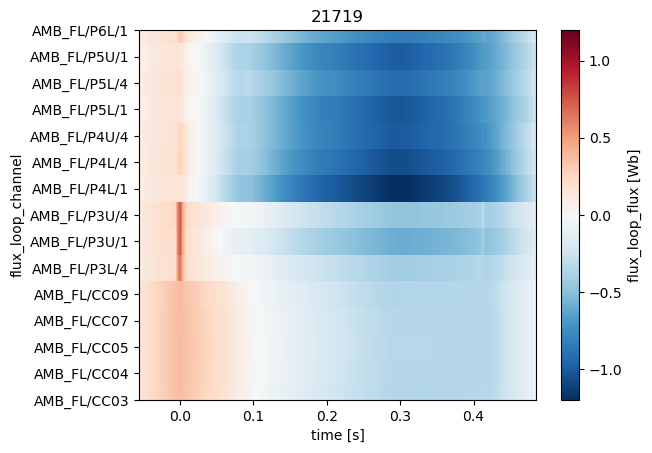

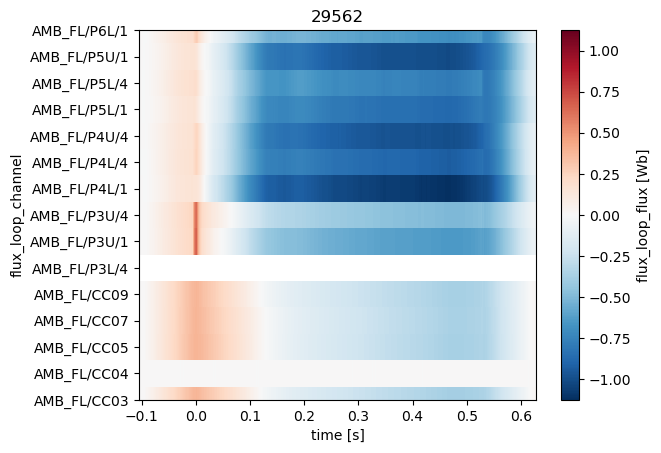

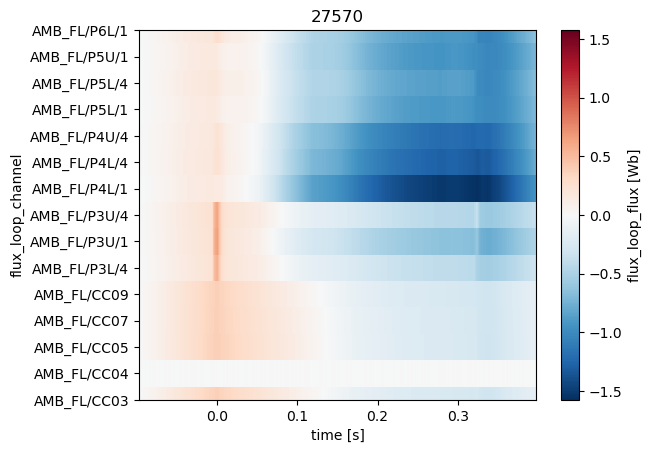

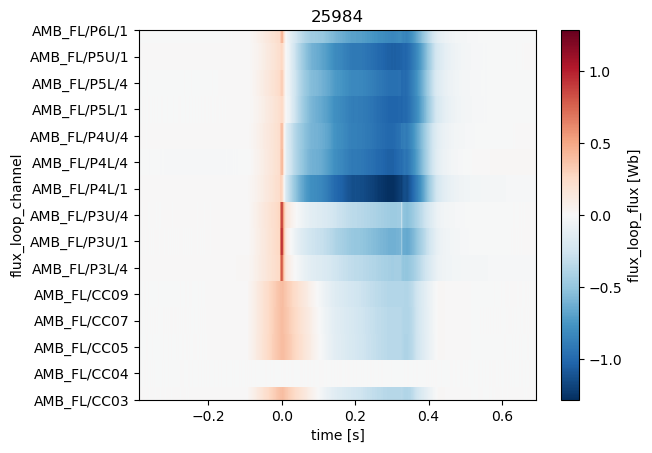

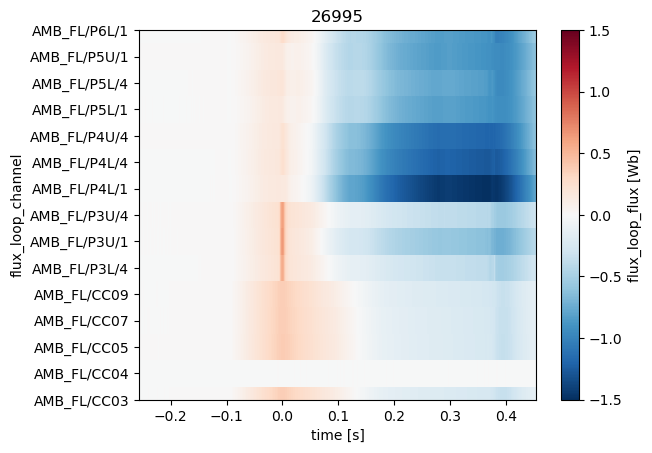

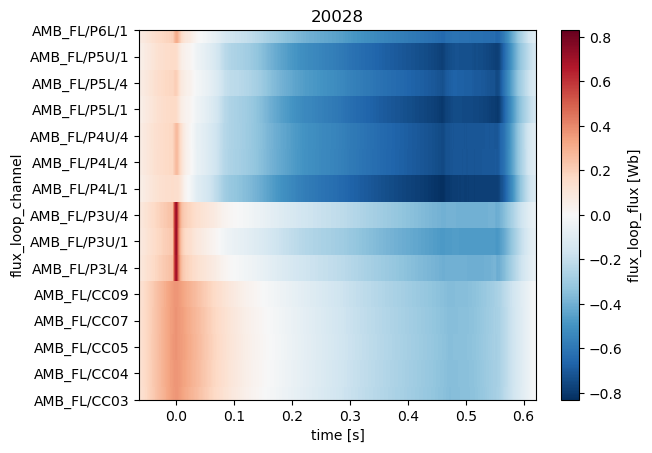

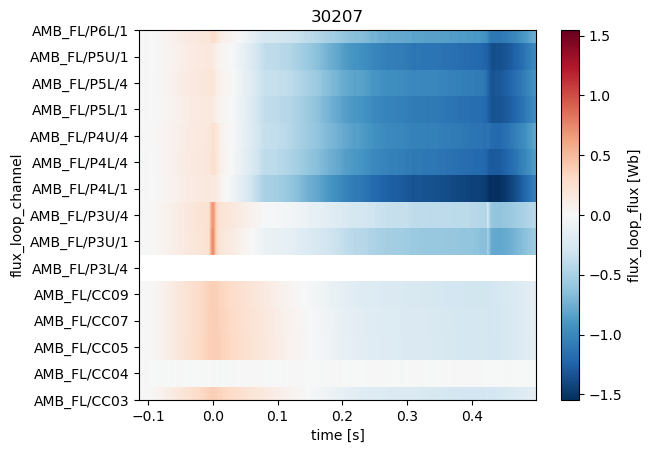

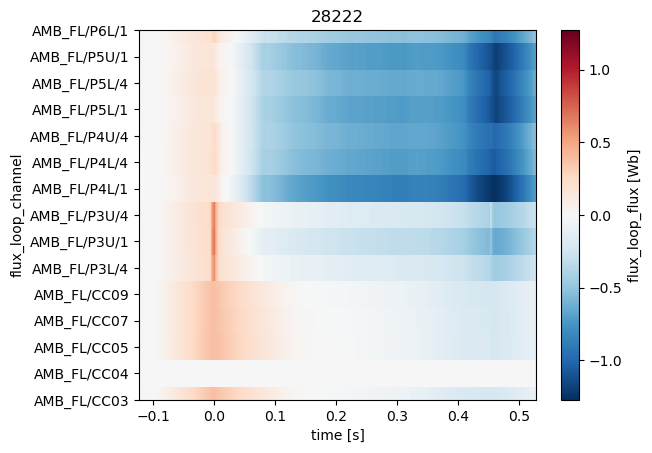

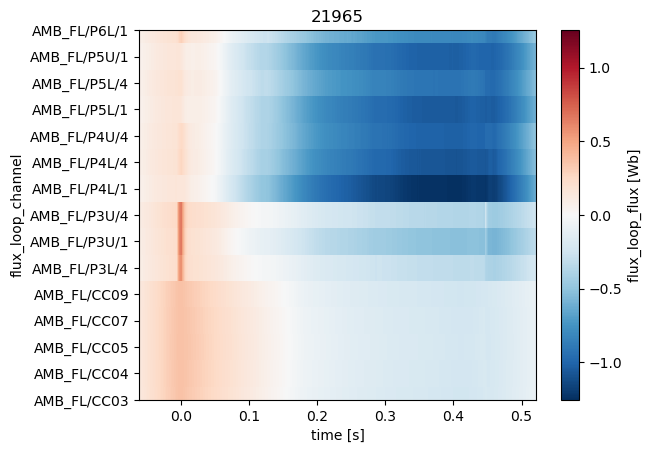

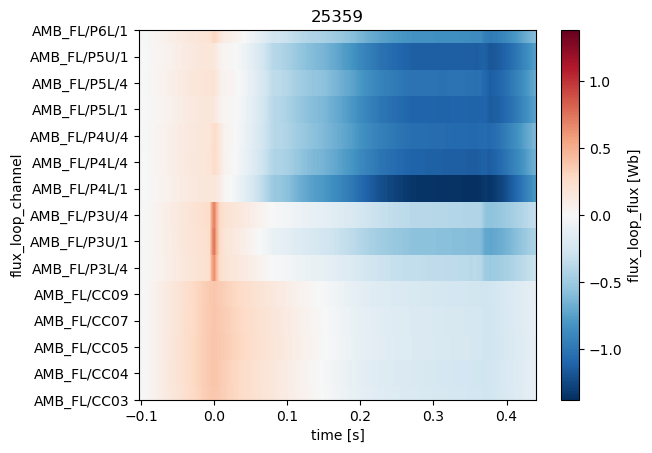

In [5]:
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm

random.seed(42)
random.shuffle(shot_ids)
random_shot_ids = shot_ids[:10]

for shot_id in tqdm(random_shot_ids):
    flux_loop = get_flux_loop(shot_id)
    fig, ax = plt.subplots()
    flux_loop.plot(ax=ax)
    ax.set_title(shot_id)

Inspect an interesting shot

[ 0.08429731  0.08531547  0.08633363 ... -0.2313752  -0.23035705
 -0.23035705]
[nan nan nan ... nan nan nan]


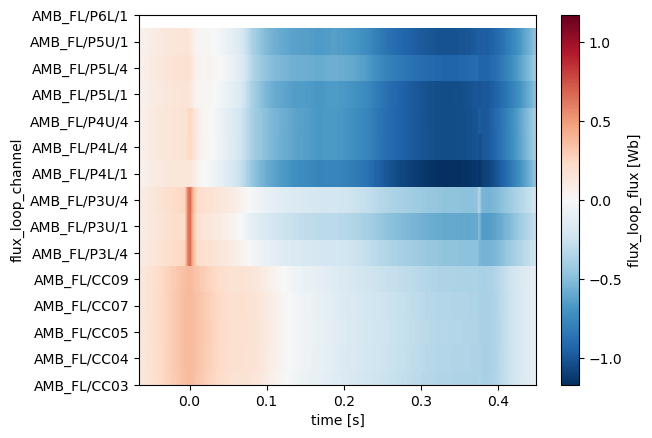

In [6]:
flux_loop = get_flux_loop(16092)

fig, ax = plt.subplots()
flux_loop.plot(ax=ax)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P3L/4").values)
print(flux_loop.sel(flux_loop_channel="AMB_FL/P6L/1").values)

PCA does not work with NaN values, so these must be imputed. Demonstrated here is imputation of NaN flux loop channel values as the mean across non-NaN channel values at the same time index.

Text(0.5, 1.0, 'Imputed')

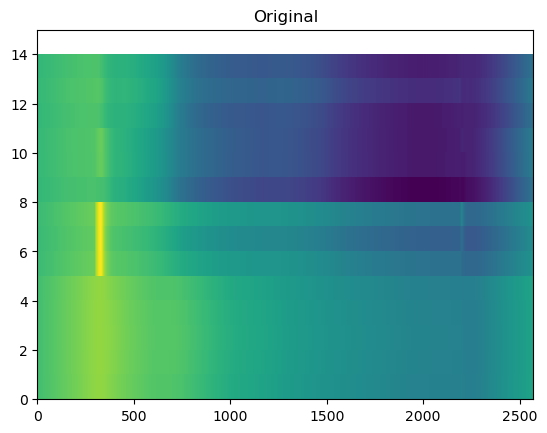

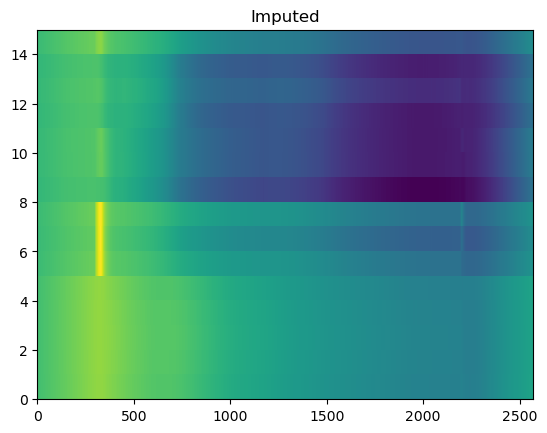

In [11]:
from sklearn.impute import SimpleImputer
import numpy as np

fig, ax = plt.subplots()
ax.pcolorfast(flux_loop.values)
ax.set_title("Original")

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
vals = flux_loop.values
imp.fit(vals)
vals = imp.transform(vals)

fig, ax = plt.subplots()
ax.pcolorfast(vals)
ax.set_title("Imputed")

Get an array of flux loops across all shots. Perform imputation as above.

In [8]:
store = get_shot_fsstore(shot_id)
profiles = xr.open_zarr(store, group="magnetics")
flux_loop_array = profiles["flux_loop_flux"].values

for shot_id in tqdm(random_shot_ids[1:]):
    flux_loop = get_flux_loop(shot_id)
    vals = flux_loop.values

    imp = SimpleImputer(missing_values=np.nan, strategy="mean")
    imp.fit(vals)
    vals = imp.transform(vals)

    flux_loop_array = np.concatenate(
        (flux_loop_array, vals),
        axis=1
    )

flux_loop_array = flux_loop_array.T
flux_loop_array.shape

  0%|          | 0/9 [00:00<?, ?it/s]

(33171, 15)

Principal component analysis

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca.fit(flux_loop_array)

explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = 0

for i, val in enumerate(explained_variance):
    cumulative_explained_variance += val
    print(f"Principal component: {i+1}")
    print(f"Explained variance: {val:.3f}")
    print(f"Cumulative explained variance: {cumulative_explained_variance:.3f}\n")

Principal component: 1
Explained variance: 0.951
Cumulative explained variance: 0.951

Principal component: 2
Explained variance: 0.029
Cumulative explained variance: 0.980

Principal component: 3
Explained variance: 0.008
Cumulative explained variance: 0.988

Principal component: 4
Explained variance: 0.006
Cumulative explained variance: 0.994

Principal component: 5
Explained variance: 0.003
Cumulative explained variance: 0.997



Demonstrate PCA transform and reconstruction

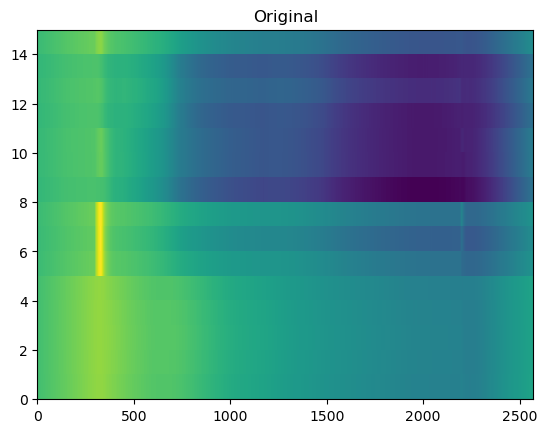

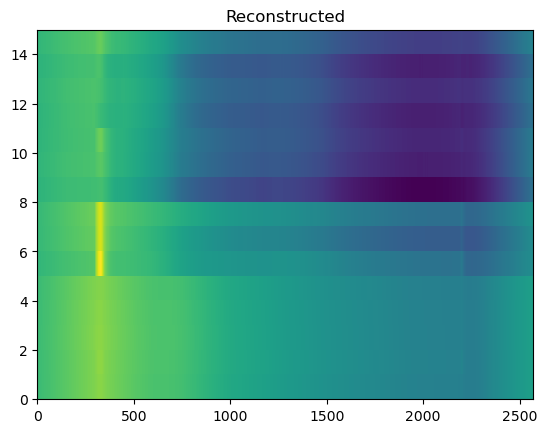

In [10]:
flux_loop = get_flux_loop(16092)
vals = flux_loop.values

imp = SimpleImputer(missing_values=np.nan, strategy="mean")
imp.fit(vals)
vals = imp.transform(vals)

transformed = pca.transform(vals.T)
reconstructed = pca.inverse_transform(transformed).T

fig, ax = plt.subplots()
ax.set_title("Original")
ax.pcolorfast(vals)

fig, ax = plt.subplots()
ax.set_title("Reconstructed")
ax.pcolorfast(reconstructed)